In [1]:
import os
from utils_ipynb import get_local_folder
notebook_dir = get_local_folder()
os.chdir(f"{notebook_dir}/..")

import json
import matplotlib.pyplot as plt

/home/zx/nas/miniconda3/envs/fedllm/lib/python3.10/site-packages/timm/models/hub.py:4: FutureWarning: Importing from timm.models.hub is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/home/zx/nas/miniconda3/envs/fedllm/lib/python3.10/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/home/zx/nas/miniconda3/envs/fedllm/lib/python3.10/site-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
05/08/2025 09:35:43 - INFO - qwen_vl_utils.vision_process -   set VIDEO_TOTAL_PIXELS: 90316800


In [2]:

from utils import init_plot
import json

fontsize = 14
max_output = True
def draw_metric(eval_ckpt_dirs, eval_epochs=[1,5,10,15,20], max_num=150, label_list=None,  title="", x_label="Round", y_label="Score", mode="acc", add_new_tokes=False, max_new_tokens=64, loc="detail", eval_datasets=["fiqa", "fpb", "tfns", "nwgi"]):

    fig, axes = init_plot(1)
    fig.set_size_inches(6,4)
    ax = axes[0]
    
    
    print("=====================Defense {}=====================".format(title))
    for idx, eval_dir in enumerate(eval_ckpt_dirs):
        # print(f"{label_list[idx]}")
        res_list = []
        
        result = None
        for epoch in eval_epochs:

            eval_result_json = os.path.join(eval_dir, f"checkpoint-{epoch}", "eval_lm_eval.json")

            if os.path.exists(eval_result_json):
                result = json.load(open(eval_result_json, 'r'))
                
            # print(eval_result_json)
            full_res_list = [result[eval_dataset][mode] for eval_dataset in eval_datasets]

            res_list.append(sum(full_res_list) / len(full_res_list))
            
        
        print(f"{label_list[idx]}: { [ round(i, 4) for i in res_list]}")
        ax.plot(res_list, label=label_list[idx] if label_list is not None else "")
            
        ax.set_ylabel(y_label, fontsize=fontsize)
        ax.set_xlabel(x_label, fontsize=fontsize)
        
        if loc == "detail":
            ax.legend(loc="upper right", fontsize=10, bbox_to_anchor=(2.0, 2.0))
        else:
            ax.legend(loc=loc, fontsize=10)
        ax.set_title(title)

=====================Defense FedAvg=====================
default_fedavg_dirichlet_tokenize_alpha_0.1_atk_clients_0: [0.5533, 0.5493]
poison_train_fedavg_dirichlet_tokenize_alpha_0.1_repeat_8: [0.5431, 0.5431]
=====================Defense Median=====================
default_median_dirichlet_tokenize_alpha_0.1_atk_clients_0: [0.5489, 0.5512]
poison_train_median_dirichlet_tokenize_alpha_0.1_repeat_8: [0.5439, 0.5484]
=====================Defense Multi-Krum=====================
default_multi-krum_dirichlet_tokenize_alpha_0.1_atk_clients_0: [0.5529, 0.5568]
poison_train_multi-krum_dirichlet_tokenize_alpha_0.1_repeat_8: [0.5443, 0.5522]
=====================Defense FLAME_0.0=====================
default_flame_0.0_dirichlet_tokenize_alpha_0.1_atk_clients_0: [0.5501, 0.56]
poison_train_flame_0.0_dirichlet_tokenize_alpha_0.1_repeat_8: [0.5511, 0.5518]


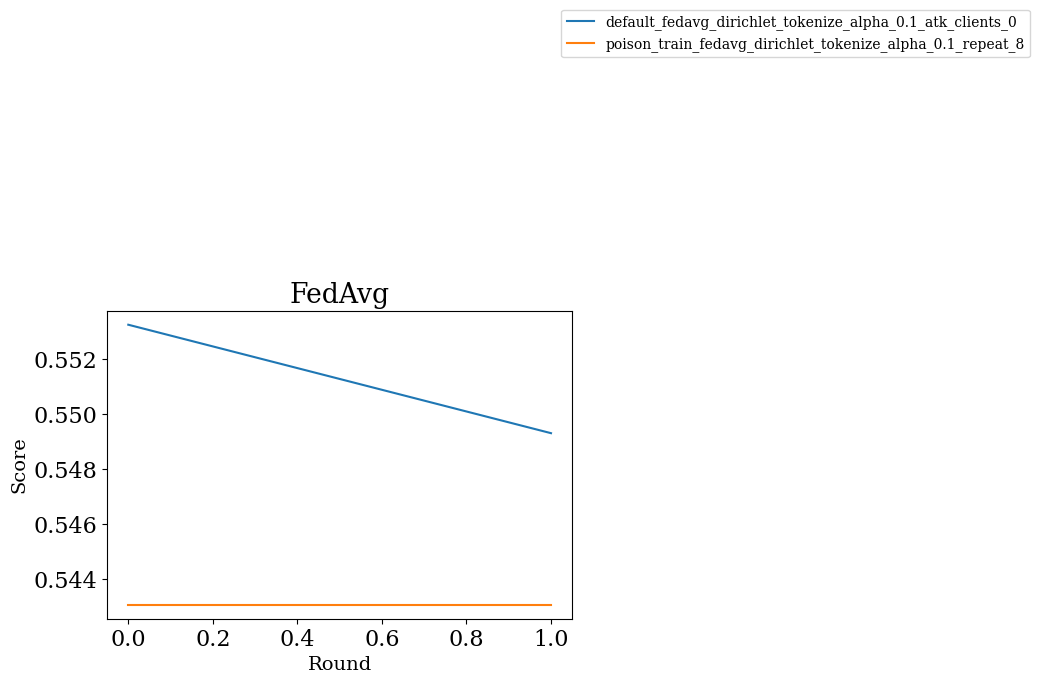

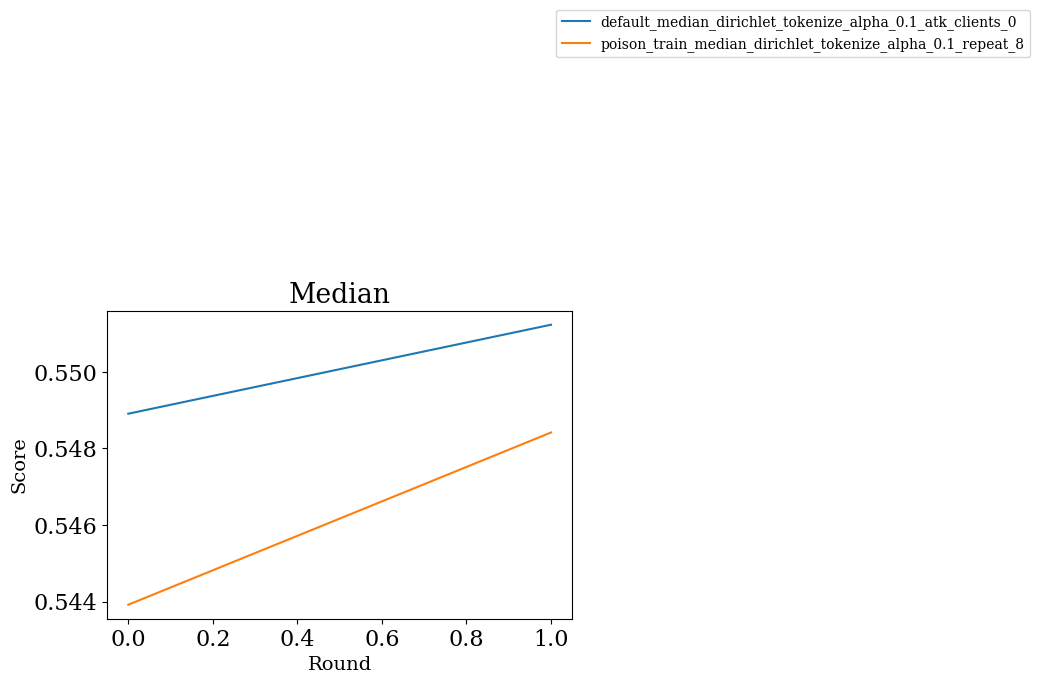

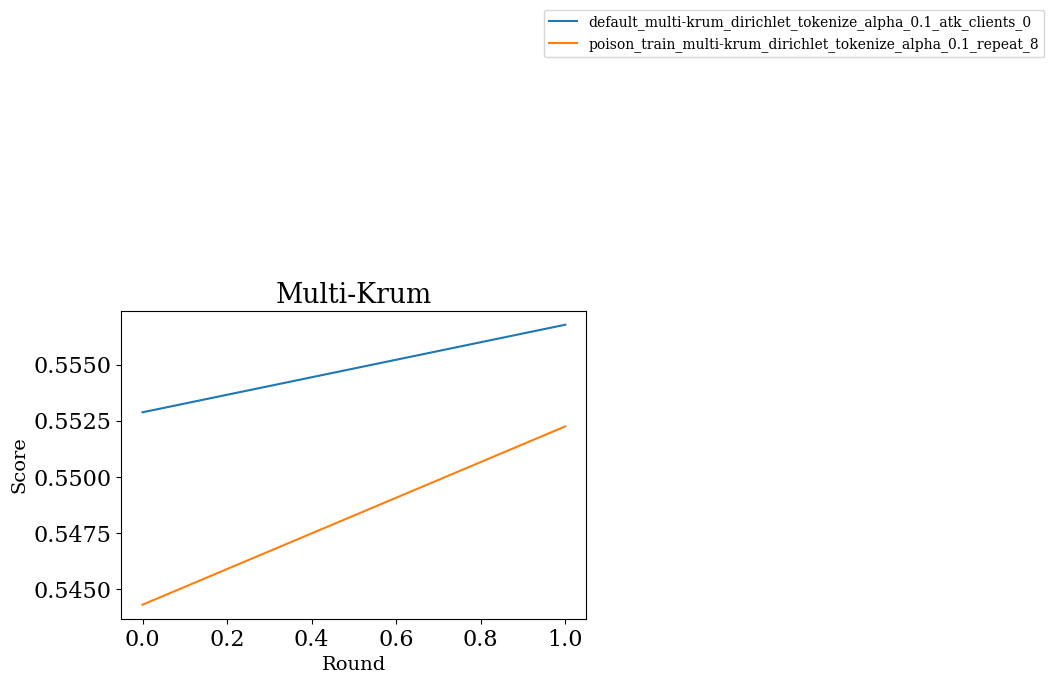

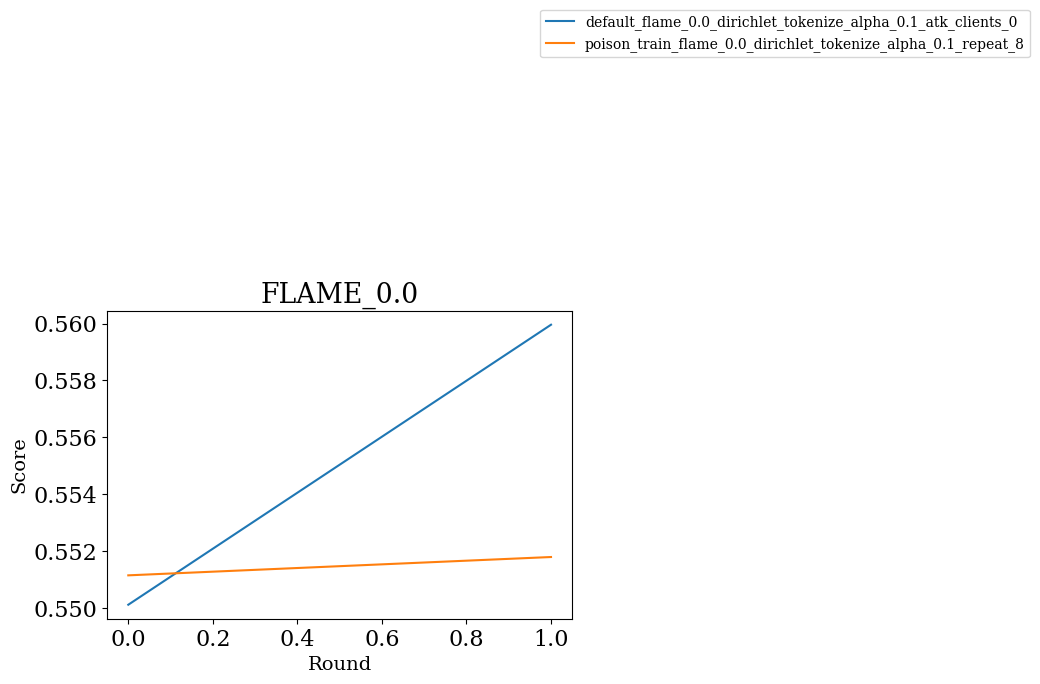

In [4]:
import json
name_dir_map_file_path = "eval_scripts/name_dir_map_tmp_c2s5_med_a100.json"

name_dir_map_file_path = "eval_scripts/medqa_name_dir_map_tmp_c2s5_a100_dirichlet_cache.json"

attacks = [
            ["default"],
        #    ["poison_train"],
           ["poison_train", "repeat_8"],

        #    ["FT-Pure/qwen2.5_3b_lora.yaml"], 
        #    ["R-ROME/qwen2.5-3b_lora_ffn_B.yaml"],  
        #    ["R-ROME/qwen2.5-3b_lora_ffn_AB.yaml"], 
        #    ["EMMET/qwen2.5-3b_lora_ffn_B.yaml"],  
        #    ["EMMET/qwen2.5-3b_lora_ffn_AB.yaml"],

        # ["FT-Plus/qwen2.5_3b_lora_20_rephrase_path_split53.yaml"],

        

]
defenses = ["FedAvg", "Median", "Multi-Krum", "FLAME_0.0"]

mode="acc,none"

eval_datasets = ["pubmedqa_alpaca", "medmcqa_alpaca", "medqa_4options_alpaca"]
eval_epochs=[15,20]
name_dir_map = json.load(open(name_dir_map_file_path, 'r'))
for d_name in defenses:
    eval_ckpt_paths = []
    labels = []
    
    for atk_name in attacks:
        label = "-".join(atk_name)
        
        for name, ckpt_dir in name_dir_map.items():
            match = 0
            for sub_atk_name in atk_name:
                if sub_atk_name.lower() in name.lower():
                    match += 1
            if d_name.lower() in name.lower():
                match += 1 
            
            if match == len(atk_name) + 1:
                eval_ckpt_paths.append(ckpt_dir)
                labels.append(name)
        
                #! 只匹配一次，如果多个name满足，只取第一个
                break
    draw_metric(eval_ckpt_paths,  label_list=labels, title=d_name, mode=mode, eval_datasets=eval_datasets, eval_epochs=eval_epochs)    

            
    
    # draw_metric(eval_ckpt_paths,  label_list=labels, title=d_name, mode=mode, eval_datasets=eval_datasets)    
    # draw_metric(eval_ckpt_paths, metric_name="total_acc_local", label_list=labels_formal, client_scatter=False, title=d_name, y_label="$ASR_s$")    
        
# draw_metric([path], metric_name="total_acc")